<a href="https://colab.research.google.com/github/sng24cs1212-debug/Machine-learning-lab/blob/main/multiple_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = {
    'Area' : [1200,1500,1800,-2400,300,
              3500,4000,4500,5000,5500],
    'Bedrooms' : [2,3,3,4,5,
                  5,6,6,7,7],
    'Age' : [10,5,8,2,1,
             3,2,4,1,2],
    'Distance' : [5,3,4,2,1,
                  2,1,3,2,1],
    'Price' : [250,320,340,450,600,
               650,700,720,800,850]

}

In [3]:
df = pd.DataFrame(data)

print("\nDATASET\n")
print(df)


DATASET

   Area  Bedrooms  Age  Distance  Price
0  1200         2   10         5    250
1  1500         3    5         3    320
2  1800         3    8         4    340
3 -2400         4    2         2    450
4   300         5    1         1    600
5  3500         5    3         2    650
6  4000         6    2         1    700
7  4500         6    4         3    720
8  5000         7    1         2    800
9  5500         7    2         1    850


In [4]:
X = df[['Area', 'Bedrooms', 'Age', 'Distance']]

y = df['Price']

In [5]:
model = LinearRegression()

In [6]:
model.fit(X, y)

LinearRegression()

In [7]:
y_pred = model.predict(X)

In [8]:
print("\nMODEL PARAMETERS\n")

print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)


MODEL PARAMETERS

Intercept:
-17.459202866434453

Coefficients:
Area : 0.0012858466951959284
Bedrooms : 122.71843045477162
Age : 10.28819341909233
Distance : -19.11923190835749


In [9]:
print("\nREGRESSION EQUATION\n")

print("Price = ")

for feature, coef in zip(X.columns, model.coef_):
    print(f"({coef:.4f} * {feature}) + ")

print(model.intercept_)


REGRESSION EQUATION

Price = 
(0.0013 * Area) + 
(122.7184 * Bedrooms) + 
(10.2882 * Age) + 
(-19.1192 * Distance) + 
-17.459202866434453


In [10]:
mse = mean_squared_error(y, y_pred)

r2 = r2_score(y, y_pred)

print("\nEVALUATION METRICS\n")

print("Mean Squared Error (MSE):", round(mse, 4))

print("R² Score:", round(r2, 4))


EVALUATION METRICS

Mean Squared Error (MSE): 580.4059
R² Score: 0.9858


In [11]:
new_house = pd.DataFrame({
    'Area': [2800],
    'Bedrooms': [4],
    'Age': [2],
    'Distance': [2]
})
predicted_price = model.predict(new_house)

print("\nNEW HOUSE PREDICTION\n")

print("Predicted House Price:",
      round(predicted_price[0], 2))


NEW HOUSE PREDICTION

Predicted House Price: 459.35


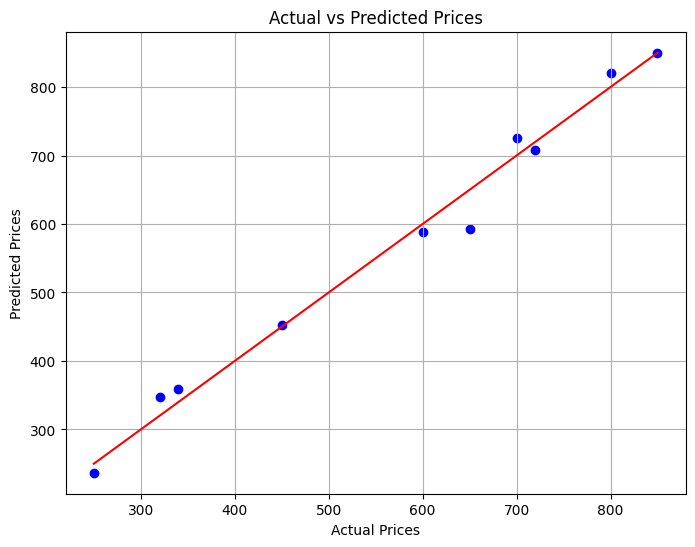

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(y, y_pred, color='blue')

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted Prices")

plt.grid(True)

plt.show()